In [8]:
import os
import time
import subprocess
import chromadb
from google import genai
from google.genai import types
from langchain_community.chat_models import ChatOllama
from langchain_core.messages import HumanMessage, SystemMessage

# ---------------------------------------------------------
# 1. Configuration & Setup
# ---------------------------------------------------------
# Replace with your actual Google API key
os.environ["GEMINI_API_KEY"] = "YOUR_GEMINI_API" # input your API key here
client = genai.Client()

# Initialize ChromaDB
DB_PATH = "./cctv_chroma_db"
chroma_client = chromadb.PersistentClient(path=DB_PATH)
# We use a new collection name to avoid mixing with any old text-based vectors
collection = chroma_client.get_or_create_collection(name="direct_video_vectors")
dimension = 768

# ---------------------------------------------------------
# 2. FFmpeg Video Utilities
# ---------------------------------------------------------
def get_video_duration(video_path):
    """Uses FFprobe to get the exact duration of the raw video."""
    cmd = ["ffprobe", "-v", "error", "-show_entries", "format=duration", 
           "-of", "default=noprint_wrappers=1:nokey=1", video_path]
    return float(subprocess.check_output(cmd).decode('utf-8').strip())

def extract_video_clip(input_path, start_sec, duration, output_path):
    """Losslessly slices a specific time window from the raw video."""
    cmd = [
        "ffmpeg", "-y", "-ss", str(start_sec), "-i", input_path, 
        "-t", str(duration), "-c", "copy", "-avoid_negative_ts", "make_zero", output_path
    ]
    subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    return output_path if os.path.exists(output_path) else None

# ---------------------------------------------------------
# 3. PHASE 1: Direct Multimodal Ingestion (Run Once)
# ---------------------------------------------------------

def ingest_raw_video_direct(video_path, chunk_duration=15.0):
    """
    Directly embeds raw video chunks into ChromaDB using INLINE DATA,
    bypassing the Google Cloud File API entirely.
    """
    video_id = os.path.splitext(os.path.basename(video_path))[0]
    duration = get_video_duration(video_path)
    
    print(f"\n=== 🎬 STARTING DIRECT MULTIMODAL INGESTION: {video_id} ({duration:.1f}s) ===")
    
    current_sec = 0.0
    chunk_idx = 0
    
    while current_sec < duration:
        end_sec = min(current_sec + chunk_duration, duration)
        clip_path = f"temp_ingest_{chunk_idx}.mp4"
        
        # 1. Extract 15-second Chunk
        extract_video_clip(video_path, current_sec, chunk_duration, clip_path)
        print(f"\n⚙️ Processing Chunk {chunk_idx} [{current_sec:.1f}s - {end_sec:.1f}s]...")
        
        try:
            # 2. READ VIDEO AS RAW BYTES (Bypasses the buggy File API)
            with open(clip_path, "rb") as f:
                video_bytes = f.read()
            
            # 3. DIRECT EMBEDDING (Inline Bytes -> Math)
            embed_response = client.models.embed_content(
                model='gemini-embedding-2-preview',
                # Pass the raw bytes directly to the model
                contents=types.Part.from_bytes(data=video_bytes, mime_type="video/mp4"),
                config=types.EmbedContentConfig(
                    task_type="RETRIEVAL_DOCUMENT",
                    output_dimensionality=dimension
                )
            )
            vector = embed_response.embeddings[0].values
            
            # 4. Save Vector to ChromaDB 
            collection.add(
                embeddings=[vector],
                documents=[""], # No text!
                metadatas=[{"video_id": video_id, "start_sec": current_sec, "end_sec": end_sec}],
                ids=[f"{video_id}_chunk_{chunk_idx}"]
            )
            print("   ✅ Video chunk embedded and saved.")
            
        except Exception as e:
            print(f"   ❌ Error processing chunk {chunk_idx}: {e}")
            
        # Clean up local file
        if os.path.exists(clip_path):
            os.remove(clip_path)
            
        current_sec += chunk_duration
        chunk_idx += 1
        
    print(f"=== 🎉 DIRECT INGESTION COMPLETE! '{video_id}' is now searchable. ===")
# ---------------------------------------------------------
# 4. PHASE 2: Chat & Retrieval (Run Anytime)
# ---------------------------------------------------------


# ---------------------------------------------------------
# 4. PHASE 2: Chat & Retrieval (LLM CONTEXT PRUNING)
# ---------------------------------------------------------
def chat_with_raw_video_direct(user_query, raw_video_path, chat_history=None):
    """
    Retrieves top matches, groups them into isolated chronological clusters, 
    extracts clips, and synthesizes an answer using dynamic LLM memory management.
    """
    if chat_history is None:
        chat_history = []

    video_id = os.path.splitext(os.path.basename(raw_video_path))[0]
    print(f"\n=== 🕵️‍♂️ CCTV ASSISTANT QUERY ===\nQuestion: '{user_query}'")

    # --- Step 1: LLM-Driven Conversational Query Rewriting (CQR) ---
    print("🦙 Asking Gemma 4 to resolve context and rewrite the query...")
    
    # Format the entire history into a readable string
    full_history_text = ""
    for idx, turn in enumerate(chat_history):
        full_history_text += f"[Turn {idx+1}] User: {turn['question']} | AI: {turn['answer']}\n"
    
    system_prompt = f"""You are an elite intent parser for a surveillance system.
Your job is to read the user's CURRENT QUERY and the FULL CHAT HISTORY, and output two things separated by a '|' character:
1. RELEVANT HISTORY: A brief summary of ONLY the facts from the history needed to understand the current query. If no history is needed, write 'NONE'.
2. REFINED QUERY: Rewrite the user's current query into a single, fully self-contained natural language sentence. Resolve any pronouns (e.g., replace "he" with "the man in the red shirt") and include necessary context from previous turns so the query makes perfect sense on its own. DO NOT output comma-separated keywords. Write it exactly as a human would ask a complete, standalone question.

FULL CHAT HISTORY:
{full_history_text if full_history_text else "No previous history."}

CURRENT QUERY: {user_query}

Respond strictly in this format: RELEVANT HISTORY | REFINED QUERY"""

    try:
        local_llm = ChatOllama(model="llama3")
        ai_message = local_llm.invoke([HumanMessage(content=system_prompt)])

        # ai_message = client.models.generate_content(
        #     model='gemma-4-9b-it', # Ensure you use the '-it' (Instruction Tuned) version
        #     contents=system_prompt
        # )
        llm_output = ai_message.content.strip()


        
        # Robust parsing: Ensure the LLM actually used the '|' delimiter
        if '|' in llm_output:
            extracted_memory, refined_query = [part.strip() for part in llm_output.split('|', 1)]
        else:
            print("⚠️ LLaMA 3 formatting error. Bypassing extraction.")
            extracted_memory = "NONE"
            refined_query = user_query
            
        print(f"🧠 Pruned Memory: {extracted_memory}")
        print(f"✨ Refined Query: {refined_query}")
        
    except Exception as e:
        print(f"⚠️ Local LangChain query rewriting failed: {e}")
        extracted_memory = "NONE"
        refined_query = user_query
    
    # --- Step 2: Embed the Refined Natural Language Query ---
    print("🔢 Embedding refined natural language query...")
    query_embed = client.models.embed_content(
        model='gemini-embedding-2-preview',
        contents=refined_query, # Now using the fully constructed sentence!
        config=types.EmbedContentConfig(
            task_type="RETRIEVAL_QUERY",
            output_dimensionality=dimension
        )
    )
    user_vector = query_embed.embeddings[0].values
    
    # --- Step 3: Search ChromaDB ---
    print("🔍 Searching Vector Database for top matches...")
    results = collection.query(
        query_embeddings=[user_vector],
        n_results=5, 
        where={"video_id": video_id}
    )
    
    if not results['metadatas'] or not results['metadatas'][0]:
        final_answer = "I could not find any events matching that description."
        chat_history.append({"question": user_query, "answer": final_answer})
        return final_answer, chat_history
        
    # --- Step 4: Multi-Cluster Logic ---
    chunks = results['metadatas'][0]
    chunks_sorted = sorted(chunks, key=lambda x: x['start_sec'])
    
    clusters = []
    current_cluster = [chunks_sorted[0]]
    
    for chunk in chunks_sorted[1:]:
        last_chunk_end = current_cluster[-1]['end_sec']
        if chunk['start_sec'] - last_chunk_end <= 45.0:
            current_cluster.append(chunk)
        else:
            clusters.append(current_cluster)
            current_cluster = [chunk]
            
    clusters.append(current_cluster)
    print(f"🧩 System identified {len(clusters)} distinct time event(s) across the video.")

    # --- Step 5: Dynamic Trimming & Inline Loading ---
    video_parts = []
    local_clip_paths = []
    clip_manifest = "CLIP TIME OFFSETS:\n"
    
    try:
        for i, cluster in enumerate(clusters):
            cluster_start = min([m['start_sec'] for m in cluster])
            cluster_end = max([m['end_sec'] for m in cluster])
            
            safe_start = max(0.0, cluster_start - 3.0)
            clip_duration = (cluster_end - safe_start) + 3.0 
            
            start_mm = int(safe_start // 60)
            start_ss = int(safe_start % 60)
            clip_manifest += f"- Clip {i+1}: Starts at absolute time {start_mm:02d}:{start_ss:02d} ({safe_start:.1f} seconds) of the original full video.\n"

            clip_path = f"temp_cluster_{i}_{int(time.time())}.mp4"
            local_clip_paths.append(clip_path)
            
            print(f"✂️ Extracting Clip {i+1}/{len(clusters)}: {safe_start:.1f}s to {safe_start+clip_duration:.1f}s...")
            extract_video_clip(raw_video_path, safe_start, clip_duration, clip_path)
            
            print(f"📦 Loading Clip {i+1} inline to bypass Cloud Storage...")
            with open(clip_path, "rb") as f:
                video_bytes = f.read()
                
            video_parts.append(
                types.Part.from_bytes(data=video_bytes, mime_type="video/mp4")
            )

        # --- Step 6: Synthesis Continuity (Using Pruned Memory) ---
        # print("🧠 Asking Gemini 2.5 Flash to synthesize an answer...")
        
#         system_prompt = f"""You are an elite CCTV analysis AI. 
# You are being provided with {len(video_parts)} chronologically ordered video clips.
# Watch all the clips closely to answer the CURRENT USER QUERY.

# INVESTIGATION CONTEXT (Extracted from past turns): 
# {extracted_memory}

# Use the Investigation Context to resolve any pronouns or track ongoing subjects. 
# Return when the event happens, which clip it happens in, and a detailed description."""

#         api_contents = video_parts + [system_prompt, f"CURRENT USER QUERY: {user_query}"]

#         response = client.models.generate_content(
#             model='gemini-2.5-flash',
#             contents=api_contents
#         )
#         final_answer = response.text

# --- Step 6: Synthesis Continuity (Using Pruned Memory) ---
        print("🧠 Asking Gemini 2.5 Flash to synthesize a structured JSON answer...")
        
        json_schema = """
        {
          "type": "object",
          "properties": {
            "event_found": {
              "type": "boolean",
              "description": "True if the queried event is found in the provided clips, False otherwise."
            },
            "overall_summary": {
              "type": "string",
              "description": "A direct, concise answer to the user's query summarizing the findings across all clips."
            },
            "occurrences": {
              "type": "array",
              "description": "A list of specific instances where the queried event or subject appears. Can contain multiple matches per clip.",
              "items": {
                "type": "object",
                "properties": {
                  "clip_number": {"type": "integer", "description": "The sequential number of the clip (e.g., 1, 2)."},
                  "start_timestamp": {"type": "string", "description": "The ABSOLUTE start time of the event from the beginning of the ORIGINAL full video (format MM:SS). Calculate this by taking the time the event happens in the temporary clip, and adding it to the clip's starting offset."},
                  "end_timestamp": {"type": "string", "description": "The ABSOLUTE end time of the event from the beginning of the ORIGINAL full video (format MM:SS)."},
                  "detailed_description": {"type": "string", "description": "Highly detailed visual description of the specific event, actors, and actions."}
                },
                "required": ["clip_number", "start_timestamp", "end_timestamp", "detailed_description"]
              }
            }
          },
          "required": ["event_found", "overall_summary", "occurrences"]
        }
        """

        system_prompt = f"""You are an elite CCTV analysis AI acting as the final synthesis layer in a surveillance retrieval pipeline. 
You are being provided with {len(video_parts)} chronologically ordered video clips that have been extracted from a longer master video.

{clip_manifest}

YOUR MISSION:
Watch all the clips closely and answer the CURRENT USER QUERY based STRICTLY on the visual evidence provided.

INVESTIGATION CONTEXT (From past conversational turns): 
{extracted_memory}
* Use this context to resolve pronouns or track ongoing subjects.

RULES FOR ANALYSIS:
1. Multiple Matches: A single clip may contain multiple distinct occurrences of the event. Log EACH occurrence as a separate object in the 'occurrences' array.
2. No Hallucinations: If the event is NOT in the video, set "event_found" to false, leave "occurrences" empty, and state that it was not found in the "overall_summary".
3. Timestamp Accuracy: You MUST output the ABSOLUTE timestamp relative to the VERY BEGINNING of the original full video, NOT the temporary clip. Use the CLIP TIME OFFSETS provided above. For example, if Clip 2 starts at absolute time 01:00, and an event happens 15 seconds into Clip 2, the absolute timestamp you output must be 01:15.

OUTPUT FORMAT:
You must output strictly valid JSON matching the following schema.
SCHEMA:
{json_schema}
"""

        api_contents = video_parts + [system_prompt, f"CURRENT USER QUERY: {user_query}"]

        # Enforce JSON output at the API configuration level
        import json
        response = client.models.generate_content(
            model='gemini-3.1-flash-lite-preview', #"gemini-2.5-flash"
            contents=api_contents,
            config=types.GenerateContentConfig(
                response_mime_type="application/json",
                temperature=0.2 # Lower temperature for highly factual/analytical output
            )
        )
        
        try:
            # Parse the response to ensure it's valid JSON
            structured_response = json.loads(response.text)
            # Dump it to a formatted string for the console (or return as dict for Streamlit)
            final_answer = json.dumps(structured_response, indent=2)
        except json.JSONDecodeError:
            final_answer = f"Error: Model failed to return valid JSON. Raw output: {response.text}"
        
#
    except Exception as e:
        final_answer = f"Error during final visual analysis: {e}"
        
    finally:
        print("🧹 Cleaning up local temporary files...")
        for l_file in local_clip_paths:
            if os.path.exists(l_file):
                os.remove(l_file)
    
    # Save this turn into the session history before returning
    chat_history.append({"question": user_query, "answer": final_answer})
    return final_answer, chat_history


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


In [ ]:
import csv
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# EXPERIMENT EVALUATION RUNNER
# ---------------------------------------------------------
CSV_FILE = "latency_evaluation_results.csv"

def init_csv():
    """Creates the CSV with headers if it doesn't exist."""
    if not os.path.exists(CSV_FILE):
        with open(CSV_FILE, mode='w', newline='') as file:
            writer = csv.writer(file)
            writer.writerow(["video_id", "video_duration_sec", "ingestion_time_sec", "query_time_sec"])

def run_single_experiment(video_path, test_query, chunk_size=20.0):
    """Runs ingestion and querying, timing both, and saves to CSV."""
    video_id = os.path.splitext(os.path.basename(video_path))[0]
    
    print(f"\n🚀 --- STARTING EXPERIMENT FOR: {video_id} ---")
    
    try:
        # 1. Get raw video duration
        duration = get_video_duration(video_path)
        
        # 2. Time the Ingestion Phase
        start_ingest = time.time()
        ingest_raw_video_direct(video_path, chunk_duration=chunk_size)
        end_ingest = time.time()
        ingest_latency = end_ingest - start_ingest
        print(f"⏱️ Ingestion took {ingest_latency:.2f} seconds.")

        # Add a small sleep to avoid hitting API rate limits too fast
        time.sleep(5) 
        
        # 3. Time the Query Phase (End-to-End Latency)
        start_query = time.time()
        answer, _ = chat_with_raw_video_direct(test_query, video_path)
        end_query = time.time()
        query_latency = end_query - start_query
        print(f"⏱️ Query took {query_latency:.2f} seconds.")
        print(f"Answer: {answer[:500]}...") # Print the first 500 chars of the answer for sanity check
        
        # 4. Save safely to CSV
        with open(CSV_FILE, mode='a', newline='') as file:
            writer = csv.writer(file)
            writer.writerow([video_id, duration, ingest_latency, query_latency])
            
        print(f"Results safely appended to {CSV_FILE}")
        
    except Exception as e:
        print(f"[ERROR] Experiment failed for {video_id}. Error: {e}")
        print("You can restart the script later without losing previous data.")


In [ ]:
# --- RUN YOUR BATCH EXPERIMENT HERE ---
if __name__ == "__main__":
    init_csv() # Initialize the file
    
    # Define your test batch. 
    # If the script fails on the second video due to tokens, comment the first one out and run again later!
    test_batch = [
        #under 1m videos
        {"path": "Videos\Abuse\Abuse046_x264.mp4" , "query": "Are there any abusive activities happening to any animals/humans?"}, #38s
        {"path": "Videos\Arrest\Arrest025_x264.mp4" , "query": "Did the police made any arrest in this situtation?"}, #35s
        {"path": "Videos\Shoplifting\Shoplifting028_x264.mp4" , "query": "Is there any shoplifting happening in the scene?"}, #45s
        {"path": "Videos\Robbery\Robbery074_x264.mp4" , "query": "Have the robber successfully entered the property?"}, #26s
        {"path": "Videos\Burglary\Burglary048_x264.mp4" , "query": "How many intruder are there in total?"}, #55s
        {"path": "Videos\Arrest\Arrest042_x264.mp4" , "query": "Did the police made any aggressive arrest in this situtation?"}, #53s

        #under 3m videos
        {"path": "Videos\Explosion\Explosion038_x264.mp4" , "query": "What was exploded in the scene?"}, #1m30s
        {"path": "Videos\Fighting\Fighting020_x264.mp4" , "query": "How many people are fighting in the first place?"}, #1m13s
        {"path": "Videos\Shooting\Shooting020_x264.mp4" , "query": "How many shooter were there?"}, #2m49s
        {"path": "Videos\Robbery\Robbery101_x264.mp4" , "query": "Was the robber armed?"}, #1m51s
        {"path": "Videos\Abuse\Abuse031_x264.mp4" , "query": "What was the abused subject?"}, #2m28s

        #under 5m videos
        # {"path": "Videos\Explosion\Explosion038_x264.mp4" , "query": "What was exploded in the scene?"}, #4m14s
        # {"path": "Videos\Fighting\Fighting020_x264.mp4" , "query": "How many people are fighting in the first place?"}, #1m13s
        # {"path": "Videos\Shooting\Shooting020_x264.mp4" , "query": "How many shooter were there?"}, #2m49s
        # {"path": "Videos\Robbery\Robbery101_x264.mp4" , "query": "Was the robber armed?"}, #1m51s
        # {"path": "Videos\Abuse\Abuse031_x264.mp4" , "query": "What was the abused subject?"}, #

        #under 10m videos
        # {"path": "Another_Folder/Very_Long_Video.mp4", "query": "What is the main theme of the video?"}

        #10m+ videos
    ]
    
    for test in test_batch:
        run_single_experiment(test["path"], test["query"])
        # Sleep for 15 seconds between videos to cool down the free-tier API limits
        time.sleep(15)

In [ ]:
# --- RUN YOUR BATCH EXPERIMENT HERE ---
if __name__ == "__main__":
    init_csv() # Initialize the file
    
    # Define your test batch. 
    # If the script fails on the second video due to tokens,  comment the first one out and run again later!
    test_batch = [
        #under 1m videos
        # {"path": "Videos\Abuse\Abuse046_x264.mp4" , "query": "Are there any abusive activities happening to any animals/humans?"}, #38s
        # {"path": "Videos\Arrest\Arrest025_x264.mp4" , "query": "Did the police made any arrest in this situtation?"}, #35s
        # {"path": "Videos\Shoplifting\Shoplifting028_x264.mp4" , "query": "Is there any shoplifting happening in the scene?"}, #45s
        # {"path": "Videos\Robbery\Robbery074_x264.mp4" , "query": "Have the robber successfully entered the property?"}, #26s
        # {"path": "Videos\Burglary\Burglary048_x264.mp4" , "query": "How many intruder are there in total?"}, #55s
        # {"path": "Videos\Arrest\Arrest042_x264.mp4" , "query": "Did the police made any aggressive arrest in this situtation?"}, #53s

        # #under 3m videos
        # {"path": "Videos\Explosion\Explosion038_x264.mp4" , "query": "What was exploded in the scene?"}, #1m30s
        # {"path": "Videos\Fighting\Fighting020_x264.mp4" , "query": "How many people are fighting in the first place?"}, #1m13s
        # {"path": "Videos\Shooting\Shooting020_x264.mp4" , "query": "How many shooter were there?"}, #2m49s
        # {"path": "Videos\Robbery\Robbery101_x264.mp4" , "query": "Was the robber armed?"}, #1m51s
        # {"path": "Videos\Abuse\Abuse031_x264.mp4" , "query": "What was the abused subject?"}, #2m28s

        #under 5m videos
        {"path": "Videos\Arrest\Arrest026_x264.mp4" , "query": "Was the suspect arrested?"}, #3m36s
        {"path": "Videos\Explosion\Explosion043_x264.mp4" , "query": "Did anything explode in the scene?"}, #4m14s
        {"path": "Videos\RoadAccidents\RoadAccidents062_x264.mp4" , "query": "How many vehicles are involved?"}, #4m08s
        {"path": "Videos\Shooting\Shooting047_x264.mp4" , "query": "Who was shot: suspect or police?"}, #4m36s
        {"path": "Videos\Robbery\Robbery081_x264.mp4" , "query": "What was robbed?"}, #3m03s
        {"path": "Videos\Abuse\Abuse008_x264.mp4" , "query": "Is there abuse happening in the scene?"}, #4m40s

        #under 10m videos
        # {"path": "Another_Folder/Very_Long_Video.mp4", "query": "What is the main theme of the video?"}

        #10m+ videos
    ]
    
    for test in test_batch:
        run_single_experiment(test["path"], test["query"])
        # Sleep for 15 seconds between videos to cool down the free-tier API limits
        time.sleep(15)


🚀 --- STARTING EXPERIMENT FOR: Arrest026_x264 ---

=== 🎬 STARTING DIRECT MULTIMODAL INGESTION: Arrest026_x264 (216.2s) ===

⚙️ Processing Chunk 0 [0.0s - 20.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 1 [20.0s - 40.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 2 [40.0s - 60.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 3 [60.0s - 80.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 4 [80.0s - 100.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 5 [100.0s - 120.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 6 [120.0s - 140.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 7 [140.0s - 160.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 8 [160.0s - 180.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 9 [180.0s - 200.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 10 [200.0s - 216.2s]...
   ✅ Video chunk embedded and s

C:\Users\vuhuy\AppData\Local\Temp\ipykernel_16104\841474494.py:144: LangChainDeprecationWarning: The class `ChatOllama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import ChatOllama``.
  local_llm = ChatOllama(model="llama3")


🧠 Pruned Memory: NONE
✨ Refined Query: Was the man in the red shirt arrested?
🔢 Embedding refined natural language query...
🔍 Searching Vector Database for top matches...
🧩 System identified 2 distinct time event(s) across the video.
✂️ Extracting Clip 1/2: 0.0s to 23.0s...
📦 Loading Clip 1 inline to bypass Cloud Storage...
✂️ Extracting Clip 2/2: 97.0s to 219.2s...
📦 Loading Clip 2 inline to bypass Cloud Storage...
🧠 Asking Gemini 2.5 Flash to synthesize a structured JSON answer...
🧹 Cleaning up local temporary files...
⏱️ Query took 52.29 seconds.
Results safely appended to latency_evaluation_results.csv

🚀 --- STARTING EXPERIMENT FOR: Explosion043_x264 ---

=== 🎬 STARTING DIRECT MULTIMODAL INGESTION: Explosion043_x264 (255.0s) ===

⚙️ Processing Chunk 0 [0.0s - 20.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 1 [20.0s - 40.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 2 [40.0s - 60.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk

In [ ]:
# --- RUN YOUR BATCH EXPERIMENT HERE ---
if __name__ == "__main__":
    init_csv() # Initialize the file
    
    # Define your test batch. 
    # If the script fails on the second video due to tokens, comment the first one out and run again later!
    test_batch = [
        #under 1m videos
        # {"path": "Videos\Abuse\Abuse046_x264.mp4" , "query": "Are there any abusive activities happening to any animals/humans?"}, #38s
        # {"path": "Videos\Arrest\Arrest025_x264.mp4" , "query": "Did the police made any arrest in this situtation?"}, #35s
        # {"path": "Videos\Shoplifting\Shoplifting028_x264.mp4" , "query": "Is there any shoplifting happening in the scene?"}, #45s
        # {"path": "Videos\Robbery\Robbery074_x264.mp4" , "query": "Have the robber successfully entered the property?"}, #26s
        # {"path": "Videos\Burglary\Burglary048_x264.mp4" , "query": "How many intruder are there in total?"}, #55s
        # {"path": "Videos\Arrest\Arrest042_x264.mp4" , "query": "Did the police made any aggressive arrest in this situtation?"}, #53s

        # #under 3m videos
        # {"path": "Videos\Explosion\Explosion038_x264.mp4" , "query": "What was exploded in the scene?"}, #1m30s
        # {"path": "Videos\Fighting\Fighting020_x264.mp4" , "query": "How many people are fighting in the first place?"}, #1m13s
        # {"path": "Videos\Shooting\Shooting020_x264.mp4" , "query": "How many shooter were there?"}, #2m49s
        # {"path": "Videos\Robbery\Robbery101_x264.mp4" , "query": "Was the robber armed?"}, #1m51s
        # {"path": "Videos\Abuse\Abuse031_x264.mp4" , "query": "What was the abused subject?"}, #2m28s

        #under 5m videos
        # {"path": "Videos\Arrest\Arrest026_x264.mp4" , "query": "Was the suspect arrested?"}, #3m36s
        # {"path": "Videos\Explosion\Explosion043_x264.mp4" , "query": "Did anything explode in the scene?"}, #4m14s
        # {"path": "Videos\RoadAccidents\RoadAccidents062_x264.mp4" , "query": "How many vehicles are involved?"}, #4m08s
        {"path": "Videos\Shooting\Shooting047_x264.mp4" , "query": "Was there any dangerous actions?"}, #4m36s
        {"path": "Videos\Robbery\Robbery081_x264.mp4" , "query": "What was robbed?"}, #3m03s
        {"path": "Videos\Abuse\Abuse008_x264.mp4" , "query": "Is there abuse happening in the scene?"}, #4m40s

        #under 10m videos
        # {"path": "Another_Folder/Very_Long_Video.mp4", "query": "What is the main theme of the video?"}

        #10m+ videos
    ]
    
    for test in test_batch:
        run_single_experiment(test["path"], test["query"])
        # Sleep for 15 seconds between videos to cool down the free-tier API limits
        time.sleep(15)


🚀 --- STARTING EXPERIMENT FOR: Shooting047_x264 ---

=== 🎬 STARTING DIRECT MULTIMODAL INGESTION: Shooting047_x264 (276.2s) ===

⚙️ Processing Chunk 0 [0.0s - 20.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 1 [20.0s - 40.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 2 [40.0s - 60.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 3 [60.0s - 80.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 4 [80.0s - 100.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 5 [100.0s - 120.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 6 [120.0s - 140.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 7 [140.0s - 160.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 8 [160.0s - 180.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 9 [180.0s - 200.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 10 [200.0s - 220.0s]...
   ✅ Video chunk embedded a

C:\Users\vuhuy\AppData\Local\Temp\ipykernel_24676\841474494.py:144: LangChainDeprecationWarning: The class `ChatOllama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import ChatOllama``.
  local_llm = ChatOllama(model="llama3")


🧠 Pruned Memory: NONE
✨ Refined Query: Were there any dangerous actions taken by anyone involved in the surveillance area?
🔢 Embedding refined natural language query...
🔍 Searching Vector Database for top matches...
🧩 System identified 2 distinct time event(s) across the video.
✂️ Extracting Clip 1/2: 0.0s to 23.0s...
📦 Loading Clip 1 inline to bypass Cloud Storage...
✂️ Extracting Clip 2/2: 77.0s to 203.0s...
📦 Loading Clip 2 inline to bypass Cloud Storage...
🧠 Asking Gemini 2.5 Flash to synthesize a structured JSON answer...
🧹 Cleaning up local temporary files...
⏱️ Query took 61.10 seconds.
Results safely appended to latency_evaluation_results.csv

🚀 --- STARTING EXPERIMENT FOR: Robbery081_x264 ---

=== 🎬 STARTING DIRECT MULTIMODAL INGESTION: Robbery081_x264 (183.3s) ===

⚙️ Processing Chunk 0 [0.0s - 20.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 1 [20.0s - 40.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 2 [40.0s - 60.0s]...
   ✅ Video chunk

In [ ]:
# --- RUN YOUR BATCH EXPERIMENT HERE ---
if __name__ == "__main__":
    init_csv() # Initialize the file
    
    # Define your test batch. 
    # If the script fails on the second video due to tokens, comment the first one out and run again later!
    test_batch = [
        #under 1m videos
        # {"path": "Videos\Abuse\Abuse046_x264.mp4" , "query": "Are there any abusive activities happening to any animals/humans?"}, #38s
        # {"path": "Videos\Arrest\Arrest025_x264.mp4" , "query": "Did the police made any arrest in this situtation?"}, #35s
        # {"path": "Videos\Shoplifting\Shoplifting028_x264.mp4" , "query": "Is there any shoplifting happening in the scene?"}, #45s
        # {"path": "Videos\Robbery\Robbery074_x264.mp4" , "query": "Have the robber successfully entered the property?"}, #26s
        # {"path": "Videos\Burglary\Burglary048_x264.mp4" , "query": "How many intruder are there in total?"}, #55s
        # {"path": "Videos\Arrest\Arrest042_x264.mp4" , "query": "Did the police made any aggressive arrest in this situtation?"}, #53s

        # #under 3m videos
        # {"path": "Videos\Explosion\Explosion038_x264.mp4" , "query": "What was exploded in the scene?"}, #1m30s
        # {"path": "Videos\Fighting\Fighting020_x264.mp4" , "query": "How many people are fighting in the first place?"}, #1m13s
        # {"path": "Videos\Shooting\Shooting020_x264.mp4" , "query": "How many shooter were there?"}, #2m49s
        # {"path": "Videos\Robbery\Robbery101_x264.mp4" , "query": "Was the robber armed?"}, #1m51s
        # {"path": "Videos\Abuse\Abuse031_x264.mp4" , "query": "What was the abused subject?"}, #2m28s

        #under 5m videos
        # {"path": "Videos\Arrest\Arrest026_x264.mp4" , "query": "Was the suspect arrested?"}, #3m36s
        # {"path": "Videos\Explosion\Explosion043_x264.mp4" , "query": "Did anything explode in the scene?"}, #4m14s
        # {"path": "Videos\RoadAccidents\RoadAccidents062_x264.mp4" , "query": "How many vehicles are involved?"}, #4m08s
        # {"path": "Videos\Shooting\Shooting047_x264.mp4" , "query": "Was there any dangerous actions?"}, #4m36s
        # {"path": "Videos\Robbery\Robbery081_x264.mp4" , "query": "What was robbed?"}, #3m03s
        # {"path": "Videos\Abuse\Abuse008_x264.mp4" , "query": "Is there abuse happening in the scene?"}, #4m40s

        #under 10m videos
        {"path": "Videos\Arson\Arson015_x264.mp4" , "query": "What was the criminal activity?"}, #5m41s
        {"path": "Videos\Burglary\Burglary045_x264.mp4" , "query": "How many burglars were there?"}, #6m05s
        {"path": "Videos\Robbery\Robbery026_x264.mp4" , "query": "Did anyone steal anything from the store?"}, #7m17s
        {"path": "Videos\Arrest\Arrest039_x264.mp4" , "query": "Have the dangerous activity been interrupted?"}, #8m47s
        {"path": "Videos\Abuse\Abuse004_x264.mp4" , "query": "Did the abuser come back to the scene?"}, #9m19s
        {"path": "Videos\Assault\Assault010_x264.mp4" , "query": "Was there any dangerous activity?"}, #8m59s

        #10m+ videos 

    ]
    
    for test in test_batch:
        run_single_experiment(test["path"], test["query"])
        # Sleep for 15 seconds between videos to cool down the free-tier API limits
        time.sleep(15)


🚀 --- STARTING EXPERIMENT FOR: Arson015_x264 ---

=== 🎬 STARTING DIRECT MULTIMODAL INGESTION: Arson015_x264 (341.0s) ===

⚙️ Processing Chunk 0 [0.0s - 20.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 1 [20.0s - 40.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 2 [40.0s - 60.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 3 [60.0s - 80.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 4 [80.0s - 100.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 5 [100.0s - 120.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 6 [120.0s - 140.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 7 [140.0s - 160.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 8 [160.0s - 180.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 9 [180.0s - 200.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 10 [200.0s - 220.0s]...
   ✅ Video chunk embedded and sav

In [ ]:
# --- RUN YOUR BATCH EXPERIMENT HERE ---
if __name__ == "__main__":
    init_csv() # Initialize the file
    
    # Define your test batch. 
    # If the script fails on the second video due to tokens, comment the first one out and run again later!
    test_batch = [
        #under 1m videos
        # {"path": "Videos\Abuse\Abuse046_x264.mp4" , "query": "Are there any abusive activities happening to any animals/humans?"}, #38s
        # {"path": "Videos\Arrest\Arrest025_x264.mp4" , "query": "Did the police made any arrest in this situtation?"}, #35s
        # {"path": "Videos\Shoplifting\Shoplifting028_x264.mp4" , "query": "Is there any shoplifting happening in the scene?"}, #45s
        # {"path": "Videos\Robbery\Robbery074_x264.mp4" , "query": "Have the robber successfully entered the property?"}, #26s
        # {"path": "Videos\Burglary\Burglary048_x264.mp4" , "query": "How many intruder are there in total?"}, #55s
        # {"path": "Videos\Arrest\Arrest042_x264.mp4" , "query": "Did the police made any aggressive arrest in this situtation?"}, #53s

        # #under 3m videos
        # {"path": "Videos\Explosion\Explosion038_x264.mp4" , "query": "What was exploded in the scene?"}, #1m30s
        # {"path": "Videos\Fighting\Fighting020_x264.mp4" , "query": "How many people are fighting in the first place?"}, #1m13s
        # {"path": "Videos\Shooting\Shooting020_x264.mp4" , "query": "How many shooter were there?"}, #2m49s
        # {"path": "Videos\Robbery\Robbery101_x264.mp4" , "query": "Was the robber armed?"}, #1m51s
        # {"path": "Videos\Abuse\Abuse031_x264.mp4" , "query": "What was the abused subject?"}, #2m28s

        #under 5m videos
        # {"path": "Videos\Arrest\Arrest026_x264.mp4" , "query": "Was the suspect arrested?"}, #3m36s
        # {"path": "Videos\Explosion\Explosion043_x264.mp4" , "query": "Did anything explode in the scene?"}, #4m14s
        # {"path": "Videos\RoadAccidents\RoadAccidents062_x264.mp4" , "query": "How many vehicles are involved?"}, #4m08s
        # {"path": "Videos\Shooting\Shooting047_x264.mp4" , "query": "Was there any dangerous actions?"}, #4m36s
        # {"path": "Videos\Robbery\Robbery081_x264.mp4" , "query": "What was robbed?"}, #3m03s
        # {"path": "Videos\Abuse\Abuse008_x264.mp4" , "query": "Is there abuse happening in the scene?"}, #4m40s

        #under 10m videos
        # {"path": "Videos\Arson\Arson015_x264.mp4" , "query": "What was the criminal activity?"}, #5m41s
        # {"path": "Videos\Burglary\Burglary045_x264.mp4" , "query": "How many burglars were there?"}, #6m05s
        # {"path": "Videos\Robbery\Robbery026_x264.mp4" , "query": "Did anyone steal anything from the store?"}, #7m17s
        # {"path": "Videos\Arrest\Arrest039_x264.mp4" , "query": "Have the dangerous activity been interrupted?"}, #8m47s
        # {"path": "Videos\Abuse\Abuse004_x264.mp4" , "query": "Did the abuser come back to the scene?"}, #9m19s
        {"path": "Videos\Arrest\Arrest012_x264.mp4" , "query": "Did the police arrive?"}, #8m58s

        #10m+ videos 
        {"path": "Videos\Shooting\Shooting032_x264.mp4" , "query": "Did anyone get injured?"}, #12m02s
        {"path": "Videos\RoadAccidents\RoadAccidents148_x264.mp4" , "query": "Any traffic accidents happened?"}, #10m02s
        {"path": "Videos\Fighting\Fighting050_x264.mp4" , "query": "Was there any conflicts?"}, #14m35s
        {"path": "Videos\Shoplifting\Shoplifting030_x264.mp4" , "query": "Is there any shoplifting happening?"}, #13m26s
        {"path": "Videos\Fighting\Fighting041_x264.mp4" , "query": "Is there any fighting happening?"}, #17m34s
    ]
    
    for test in test_batch:
        run_single_experiment(test["path"], test["query"])
        # Sleep for 15 seconds between videos to cool down the free-tier API limits
        time.sleep(15)


🚀 --- STARTING EXPERIMENT FOR: Arrest012_x264 ---

=== 🎬 STARTING DIRECT MULTIMODAL INGESTION: Arrest012_x264 (538.7s) ===

⚙️ Processing Chunk 0 [0.0s - 20.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 1 [20.0s - 40.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 2 [40.0s - 60.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 3 [60.0s - 80.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 4 [80.0s - 100.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 5 [100.0s - 120.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 6 [120.0s - 140.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 7 [140.0s - 160.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 8 [160.0s - 180.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 9 [180.0s - 200.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 10 [200.0s - 220.0s]...
   ✅ Video chunk embedded and s

C:\Users\vuhuy\AppData\Local\Temp\ipykernel_24968\841474494.py:144: LangChainDeprecationWarning: The class `ChatOllama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import ChatOllama``.
  local_llm = ChatOllama(model="llama3")


🧠 Pruned Memory: NONE
✨ Refined Query: When did the police arrive?
🔢 Embedding refined natural language query...
🔍 Searching Vector Database for top matches...
🧩 System identified 2 distinct time event(s) across the video.
✂️ Extracting Clip 1/2: 177.0s to 243.0s...
📦 Loading Clip 1 inline to bypass Cloud Storage...
✂️ Extracting Clip 2/2: 297.0s to 443.0s...
📦 Loading Clip 2 inline to bypass Cloud Storage...
🧠 Asking Gemini 2.5 Flash to synthesize a structured JSON answer...
🧹 Cleaning up local temporary files...
⏱️ Query took 68.87 seconds.
Answer: {
  "event_found": true,
  "overall_summary": "Police officers are visible in both clips, with flashing blue lights from a police vehicle also present in the background throughout the video. They appear to be managing the crowd.",
  "occurrences": [
    {
      "clip_number": 1,
      "start_timestamp": "02:57",
      "end_timestamp": "03:59",
      "detailed_description": "Flashing blue lights, indicative of a police vehicle, are visible 

KeyboardInterrupt: 

In [ ]:
# --- RUN YOUR BATCH EXPERIMENT HERE ---
if __name__ == "__main__":
    init_csv() # Initialize the file
    
    # Define your test batch. 
    # If the script fails on the second video due to tokens, comment the first one out and run again later!
    test_batch = [
        #under 1m videos
        # {"path": "Videos\Abuse\Abuse046_x264.mp4" , "query": "Are there any abusive activities happening to any animals/humans?"}, #38s
        # {"path": "Videos\Arrest\Arrest025_x264.mp4" , "query": "Did the police made any arrest in this situtation?"}, #35s
        # {"path": "Videos\Shoplifting\Shoplifting028_x264.mp4" , "query": "Is there any shoplifting happening in the scene?"}, #45s
        # {"path": "Videos\Robbery\Robbery074_x264.mp4" , "query": "Have the robber successfully entered the property?"}, #26s
        # {"path": "Videos\Burglary\Burglary048_x264.mp4" , "query": "How many intruder are there in total?"}, #55s
        # {"path": "Videos\Arrest\Arrest042_x264.mp4" , "query": "Did the police made any aggressive arrest in this situtation?"}, #53s

        # #under 3m videos
        # {"path": "Videos\Explosion\Explosion038_x264.mp4" , "query": "What was exploded in the scene?"}, #1m30s
        # {"path": "Videos\Fighting\Fighting020_x264.mp4" , "query": "How many people are fighting in the first place?"}, #1m13s
        # {"path": "Videos\Shooting\Shooting020_x264.mp4" , "query": "How many shooter were there?"}, #2m49s
        # {"path": "Videos\Robbery\Robbery101_x264.mp4" , "query": "Was the robber armed?"}, #1m51s
        # {"path": "Videos\Abuse\Abuse031_x264.mp4" , "query": "What was the abused subject?"}, #2m28s

        #under 5m videos
        # {"path": "Videos\Arrest\Arrest026_x264.mp4" , "query": "Was the suspect arrested?"}, #3m36s
        # {"path": "Videos\Explosion\Explosion043_x264.mp4" , "query": "Did anything explode in the scene?"}, #4m14s
        # {"path": "Videos\RoadAccidents\RoadAccidents062_x264.mp4" , "query": "How many vehicles are involved?"}, #4m08s
        # {"path": "Videos\Shooting\Shooting047_x264.mp4" , "query": "Was there any dangerous actions?"}, #4m36s
        # {"path": "Videos\Robbery\Robbery081_x264.mp4" , "query": "What was robbed?"}, #3m03s
        # {"path": "Videos\Abuse\Abuse008_x264.mp4" , "query": "Is there abuse happening in the scene?"}, #4m40s

        #under 10m videos
        # {"path": "Videos\Arson\Arson015_x264.mp4" , "query": "What was the criminal activity?"}, #5m41s
        # {"path": "Videos\Burglary\Burglary045_x264.mp4" , "query": "How many burglars were there?"}, #6m05s
        # {"path": "Videos\Robbery\Robbery026_x264.mp4" , "query": "Did anyone steal anything from the store?"}, #7m17s
        # {"path": "Videos\Arrest\Arrest039_x264.mp4" , "query": "Have the dangerous activity been interrupted?"}, #8m47s
        # # {"path": "Videos\Abuse\Abuse004_x264.mp4" , "query": "Did the abuser come back to the scene?"}, #9m19s
        # {"path": "Videos\Arrest\Arrest012_x264.mp4" , "query": "Did the police arrive?"}, #8m58s

        # #10m+ videos 
        # {"path": "Videos\Shooting\Shooting032_x264.mp4" , "query": "Did anyone get injured?"}, #12m02s
        # {"path": "Videos\RoadAccidents\RoadAccidents148_x264.mp4" , "query": "Any traffic accidents happened?"}, #10m02s
        {"path": "Videos\Fighting\Fighting050_x264.mp4" , "query": "Was there any conflicts?"}, #14m35s
        {"path": "Videos\Shoplifting\Shoplifting030_x264.mp4" , "query": "Is there any shoplifting happening?"}, #13m26s
        {"path": "Videos\Fighting\Fighting041_x264.mp4" , "query": "Is there any fighting happening?"}, #17m34s
    ]
    
    for test in test_batch:
        run_single_experiment(test["path"], test["query"])
        # Sleep for 15 seconds between videos to cool down the free-tier API limits
        time.sleep(15)


🚀 --- STARTING EXPERIMENT FOR: Fighting050_x264 ---

=== 🎬 STARTING DIRECT MULTIMODAL INGESTION: Fighting050_x264 (875.5s) ===

⚙️ Processing Chunk 0 [0.0s - 20.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 1 [20.0s - 40.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 2 [40.0s - 60.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 3 [60.0s - 80.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 4 [80.0s - 100.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 5 [100.0s - 120.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 6 [120.0s - 140.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 7 [140.0s - 160.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 8 [160.0s - 180.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 9 [180.0s - 200.0s]...
   ✅ Video chunk embedded and saved.

⚙️ Processing Chunk 10 [200.0s - 220.0s]...
   ✅ Video chunk embedded a

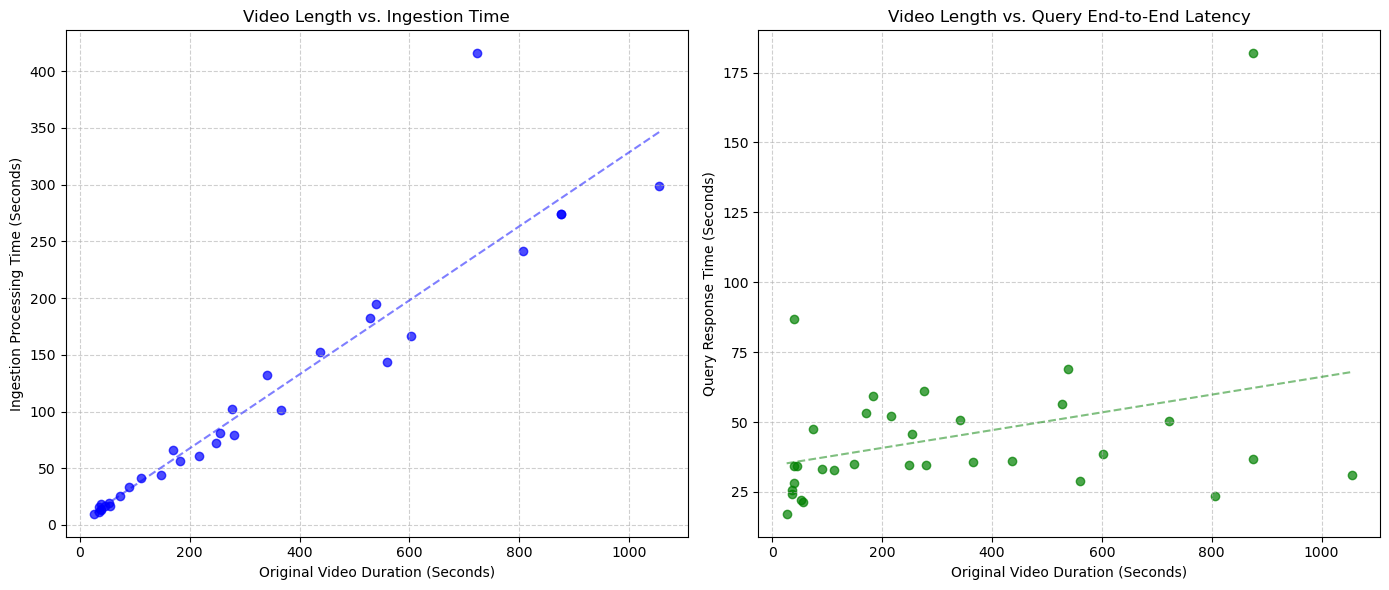

In [18]:
import pandas as pd
import numpy as np

def plot_evaluation_results(csv_filepath):
    # Read the data we saved
    df = pd.read_csv(csv_filepath)
    
    # Sort by duration to make the line graphs look clean
    df = df.sort_values(by="video_duration_sec")
    
    plt.figure(figsize=(14, 6))

    # --- Plot 1: Video Length vs. Ingestion Time ---
    plt.subplot(1, 2, 1)
    plt.scatter(df["video_duration_sec"], df["ingestion_time_sec"], color='blue', alpha=0.7)
    # Add a trendline
    z = np.polyfit(df["video_duration_sec"], df["ingestion_time_sec"], 1)
    p = np.poly1d(z)
    plt.plot(df["video_duration_sec"], p(df["video_duration_sec"]), "b--", alpha=0.5)
    
    plt.title('Video Length vs. Ingestion Time')
    plt.xlabel('Original Video Duration (Seconds)')
    plt.ylabel('Ingestion Processing Time (Seconds)')
    plt.grid(True, linestyle='--', alpha=0.6)

    # --- Plot 2: Video Length vs. Query Response Time ---
    plt.subplot(1, 2, 2)
    plt.scatter(df["video_duration_sec"], df["query_time_sec"], color='green', alpha=0.7)
    
    # Add a trendline
    z2 = np.polyfit(df["video_duration_sec"], df["query_time_sec"], 1)
    p2 = np.poly1d(z2)
    plt.plot(df["video_duration_sec"], p2(df["video_duration_sec"]), "g--", alpha=0.5)
    
    plt.title('Video Length vs. Query End-to-End Latency')
    plt.xlabel('Original Video Duration (Seconds)')
    plt.ylabel('Query Response Time (Seconds)')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Run the plotter
plot_evaluation_results(CSV_FILE)